In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import matplotlib as mpl
import os
import re

mpl.rcParams['text.usetex'] = False
plt.rcParams.update({
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['cmr10'],
    'axes.formatter.use_mathtext': True,
    'axes.unicode_minus': False,
})

from cosmo_hydro_emu.pca import *
from cosmo_hydro_emu.viz import *
from cosmo_hydro_emu.load_hacc import *
from cosmo_hydro_emu.emu import *
from cosmo_hydro_emu.gp import *
# from hydro_emu.mcmc import *

# Load files -- all summary stats

In [2]:
DirIn = '../data/scidac-olcf-pk_3/'

save_model = 'False'

start_sim_idx = 1 #40 #1
num_sims = 39 # 49 #39
exp_variance = 0.95

side_length = 400 #Mpc/h
Npart =  1024

if_plot_sensi = True

In [3]:
def read_params(fileIn):
    params_all = np.loadtxt(fileIn, delimiter=",", skiprows=1)
    end_sim_idx = start_sim_idx + num_sims
    print('Loaded file with params: ', params_all.shape)
    return params_all[start_sim_idx:end_sim_idx]
    # kappa_W,e_W,M_seed,v_kin,eps_kin,omega_m,sigma_8
    

fileIn = '/home/nramachandra/Projects/Hydro_runs/CosmoHydro/data/FinalDesign.txt'

params32 = read_params(fileIn)

seed_mass_scale = 1e6
vkin_scale = 1e4
eps_scale = 1e1

params32[:, 2] = params32[:, 2]/seed_mass_scale
params32[:, 3] = params32[:, 3]/vkin_scale
params32[:, 4] = params32[:, 4]/eps_scale

PARAM_NAME = ['$\\kappa_\\text{w}$',
                '$e_\\text{w}$',
                '$M_\\text{seed}/10^{6}$',
                '$v_\\text{kin}/10^{4}$',
                '$\\epsilon_\\text{kin}/10^{1}$', 
                '$\\omega_\\text{m}$',
                '$\\sigma_\\text{8}$'
                ]

Loaded file with params:  (110, 7)


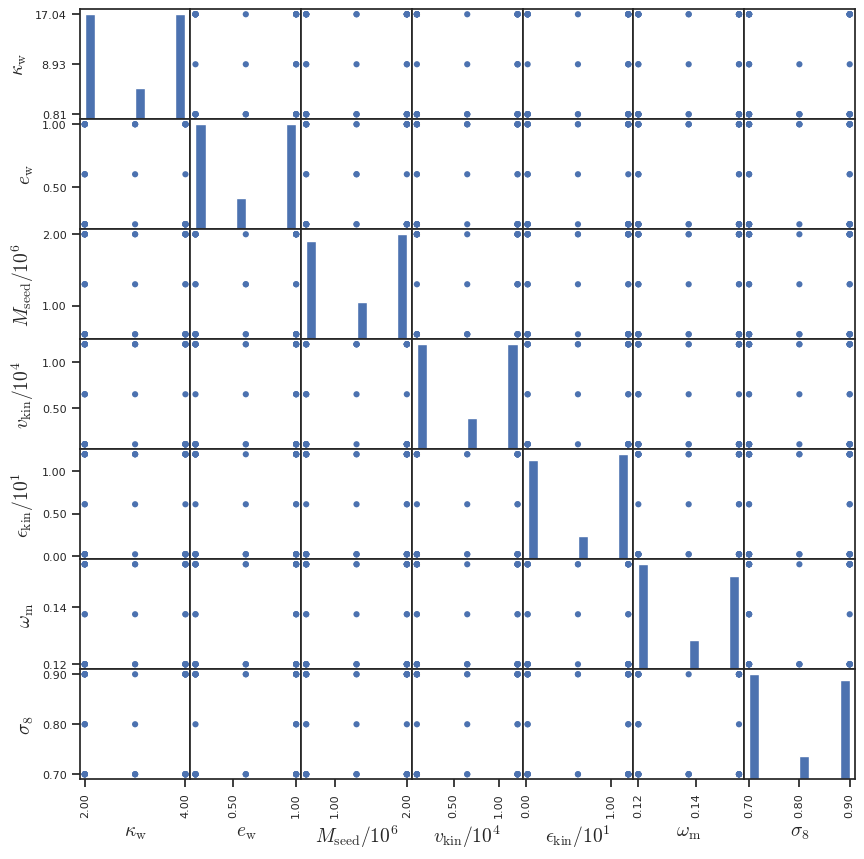

In [4]:
# Print the numpy array

        
df_train_a = pd.DataFrame(params32, columns=PARAM_NAME)
colors = ['b']*params32.shape[0]
# colors = ['b']*num_sims + ['r']*num_sims_test
plot_scatter_matrix(df_train_a, colors);
plt.savefig('../plots/exp_design_pk.png', bbox_inches='tight')

In [5]:
k, pk_arr, pk_go_arr, pk_ratio = read_pk_new(DirIn, num_sims, redshift='0.0', pk_type='hydro.full', start_sim_idx=start_sim_idx)

(0.015707963267948967, 8.042477193189871, 0.0222491, 21.75653)

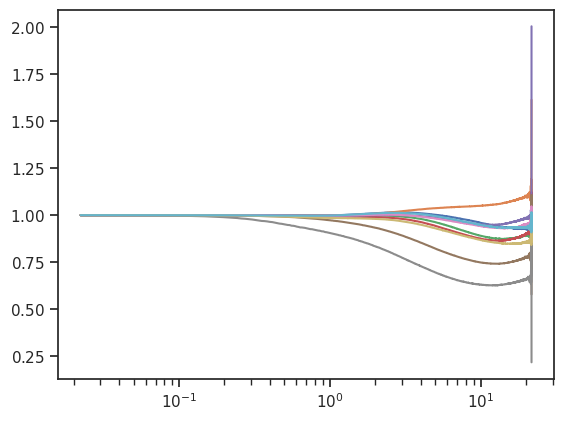

In [6]:
plt.plot(k, pk_ratio[0:10].T)
plt.xscale('log')
# plt.yscale('log')

k_min = 2*np.pi/side_length
delta_x = side_length/Npart
k_max = np.pi/delta_x #Nyquist

k_min, k_max, k.min(), k.max()

# Visualize -- all summary stats with parameter dependence + obs data

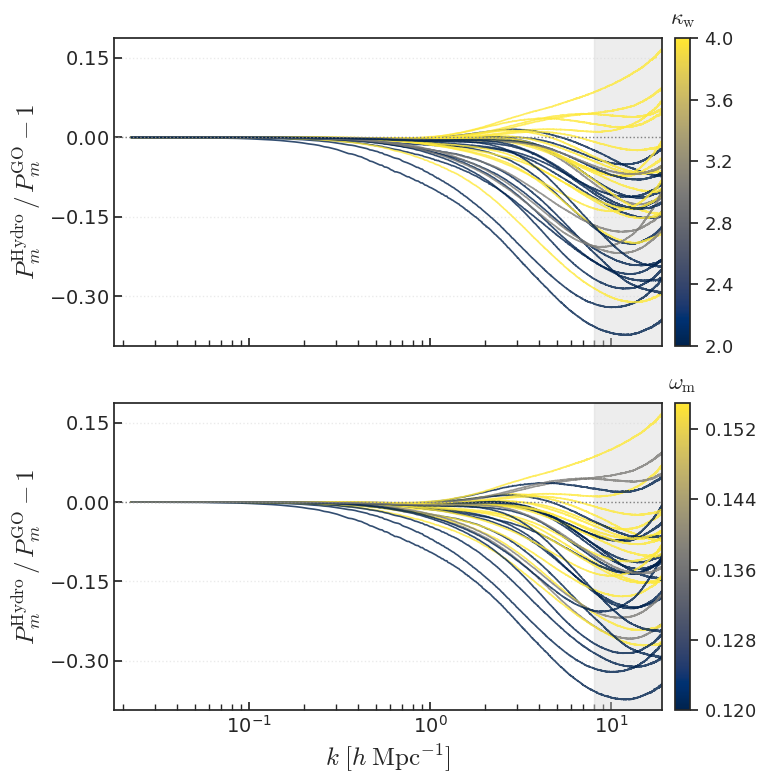

In [7]:
color_index_top = 0    # 4 = eps_kin
color_index_bottom = 5 # 6=sigma_8

plt_strings = plot_strings('Pk')
mlim1, mlim2 = mass_conds('Pk')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

pk_suppression = pk_ratio - 1.0

k_xlim = 19.0
k_mask = k < k_xlim
y_min = pk_suppression[:, k_mask].min()
y_max = pk_suppression[:, k_mask].max()
y_pad = 0.02

for ax, ci in [(ax1, color_index_top), (ax2, color_index_bottom)]:
    import matplotlib as mpl
    norm = mpl.colors.Normalize(vmin=params32[:, ci].min(), vmax=params32[:, ci].max())
    cmap_obj = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.cividis)
    cmap_obj.set_array([])

    for sim_index in range(num_sims):
        ax.plot(k, pk_suppression[sim_index], '-', alpha=0.8, lw=1.2,
                c=cmap_obj.to_rgba(params32[sim_index, ci]))

    ax.axhline(y=0.0, ls=':', color='gray', lw=1.0)

    k_nyquist = np.pi / (side_length / Npart)
    ax.axvspan(k_nyquist, k_xlim * 1.5, color='lightgray', alpha=0.4)

    ax.set_xscale('log')
    ax.tick_params(axis='both', which='major', labelsize=14, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=11, direction='in')
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=4))
    ax.grid(axis='y', ls=':', alpha=0.4)
    ax.set_xlim(k.min() * 0.8, k_xlim)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    ax.set_ylabel(r'$P_m^{\mathrm{Hydro}} \, / \, P_m^{\mathrm{GO}} - 1$', fontsize=18)

    clb = fig.colorbar(cmap_obj, ax=ax, pad=0.02)
    clb.ax.tick_params(labelsize=13)
    clb.ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=5))
    clb.ax.set_title(PARAM_NAME[ci], fontsize=16, pad=10)

ax2.set_xlabel(r'$k \; [h \; \mathrm{Mpc}^{-1}]$', fontsize=18)

fig.tight_layout()
plt.savefig('../plots/Pk_design.png', bbox_inches='tight', dpi=150)

# Emulate stat-1: P(k) suppression

0.6427635015919014 1.0854462192002552
This SepiaData instance implies the following:
This is a simulator (eta)-only model, y dimension 511
m  =    36 (number of simulated data)
p  =     1 (number of inputs)
q  =     7 (number of additional simulation inputs)
pu NOT SET (transformed response dimension); call method create_K_basis 

Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1]
 [0.1]
 [0.1]
 [0.1]
 [0.1]
 [0.1]
 [0.1]
 [0.1]]
lamUz
[[5.]]
lamWs
[[100.]]
lamWOs
[[100.]]


Step size tuning:   0%|          | 0/50 [00:00<?, ?it/s]

Step size tuning: 100%|██████████| 50/50 [00:04<00:00, 12.01it/s]


Done with tune_step_size.
Selected step sizes:
betaU
[[0.27504294]
 [0.42277991]
 [0.18098146]
 [0.11469935]
 [0.33065851]
 [1.04080762]
 [0.10965267]
 [0.0888861 ]]
lamUz
[[1.46978368]]
lamWs
[[4169.89597694]]
lamWOs
[[7.91358001]]


MCMC sampling: 100%|██████████| 1000/1000 [00:03<00:00, 257.05it/s]


Model saved to ../models/Pk_multivariate_model_z_index0.pkl
No thetas to plot


(None, <Figure size 1000x750 with 5 Axes>)

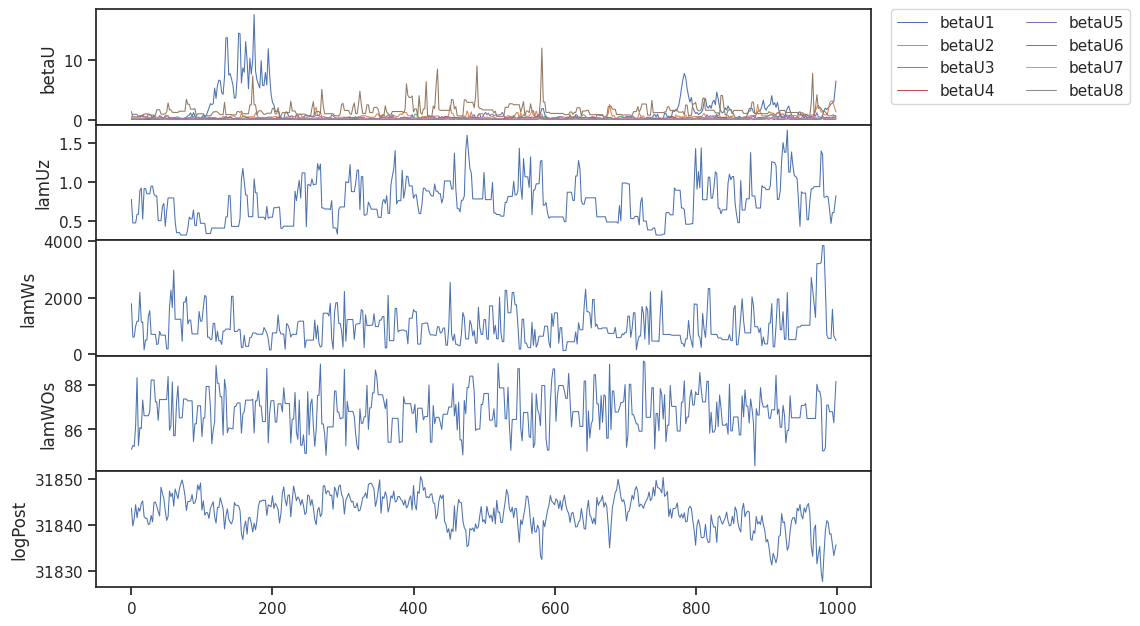

In [8]:
## Data prep
z_index = 0

plt_strings = plot_strings('Pk')
mlim1, mlim2 = mass_conds('Pk')
mass_cond = np.where( (k > mlim1)  &  (k < mlim2) ) 
# mass_cond = True

p_all = params32
y_vals =  pk_ratio[:, mass_cond][:, 0, :]

y_ind = k[mass_cond]#[0]

print(y_vals.min(), y_vals.max())

#################################################################

# Train-test split
test_indices = [3, 14, 35]

input_params= p_all[test_indices]
target_vals = y_vals[test_indices]

train_indices = [i for i in  np.arange(num_sims) if i not in test_indices] 
p_all_train = p_all[train_indices]
y_vals_train = y_vals[train_indices]

#################################################################

## Fitting
sepia_data = sepia_data_format(p_all_train, y_vals_train, y_ind)
print(sepia_data)
model_filename = '../models/Pk_multivariate_model_z_index' + str(z_index) 

sepia_model = do_pca(sepia_data, exp_variance=exp_variance)
sepia_model = do_gp_train(sepia_model, model_filename)
sepia_model = gp_load(sepia_model, model_filename)
plot_train_diagnostics(sepia_model)

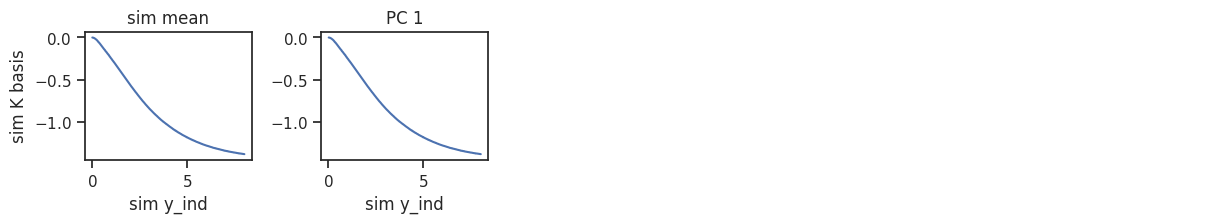

In [9]:
from sepia import SepiaPlot
SepiaPlot.plot_K_basis(sepia_data, max_plots=1);

Maximum relative error (mean): 0.0276 (2.76%)
Mean relative error (mean): 0.0115 (1.15%)
Maximum relative error (quantiles): 0.0802 (8.02%)
Mean relative error (quantiles): 0.0458 (4.58%)
0.7276921204708546 1.0921066340356818


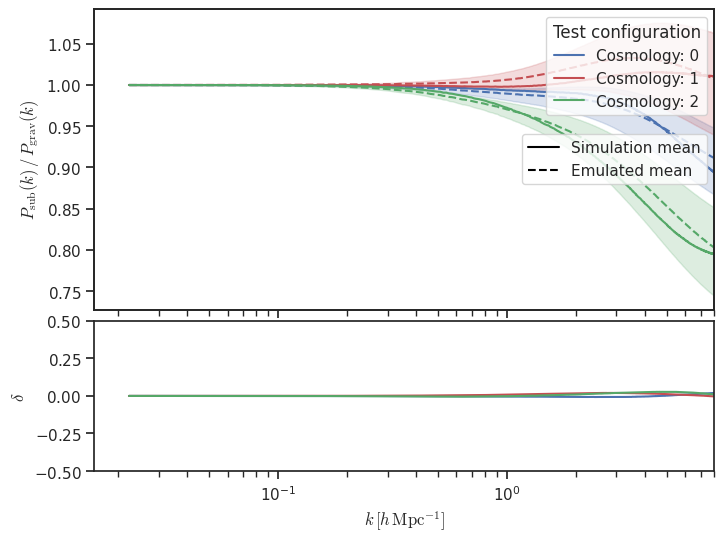

In [10]:
pred_mean, pred_quant = emulate(sepia_model, input_params)

validation_plot( y_ind, target_vals, pred_mean, pred_quant, *plt_strings, mlim1, mlim2, 'log', 'linear');
plt.savefig('../plots/Pk_valid.png', bbox_inches='tight')

In [11]:
# sensitivity_plot is imported from cosmo_hydro_emu.viz

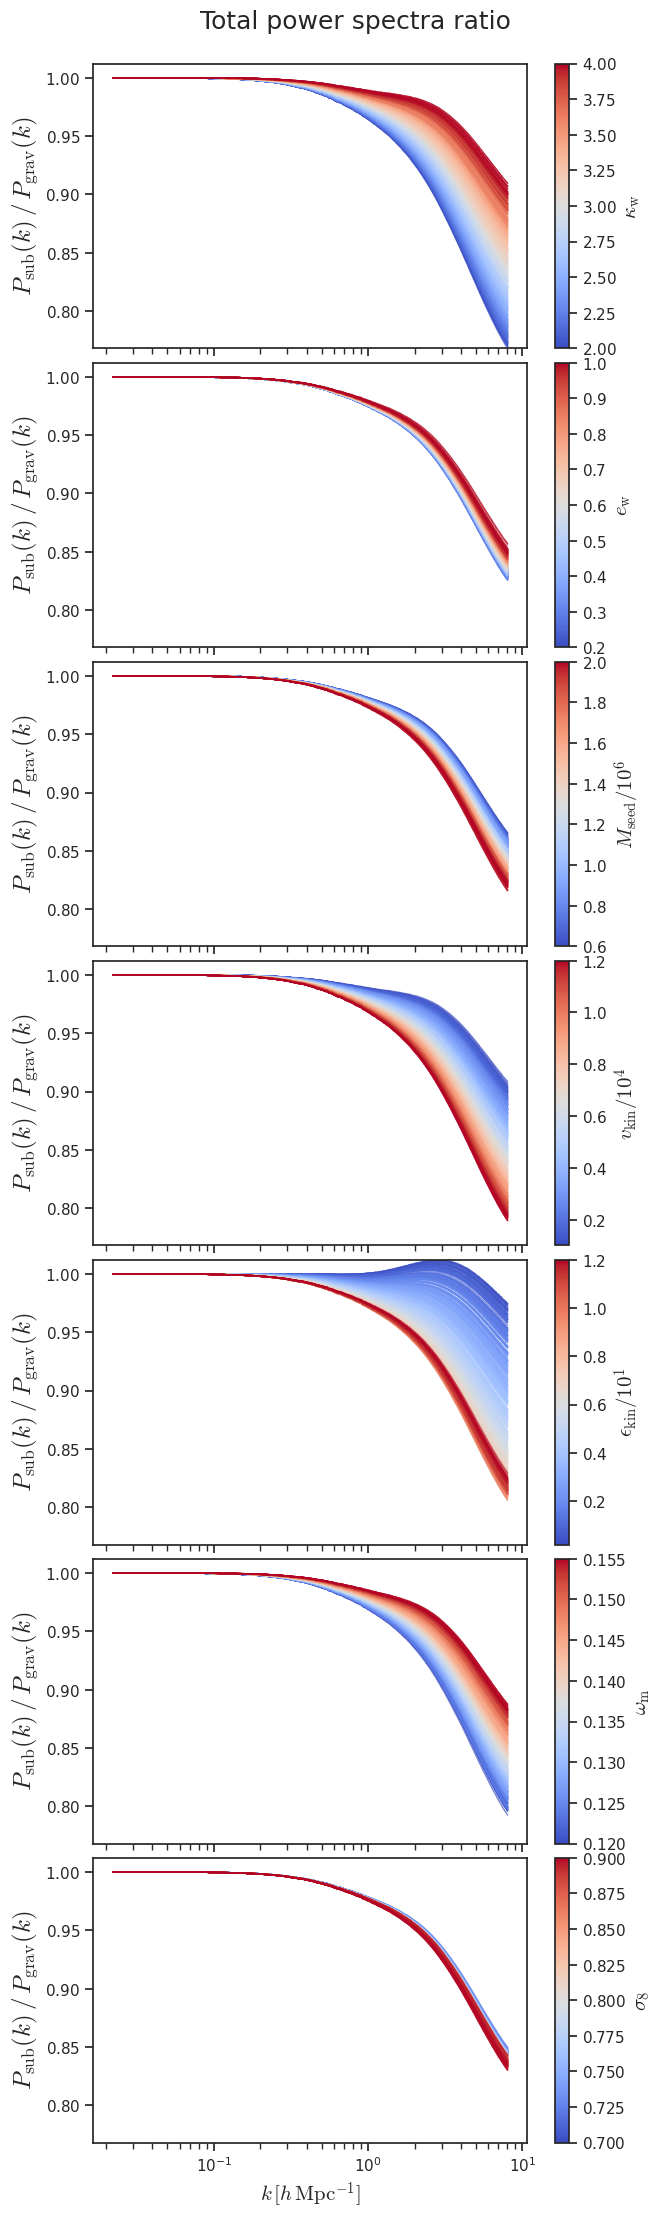

In [12]:
if if_plot_sensi:
    f = sensitivity_plot( y_ind, p_all, sepia_model, emulate, PARAM_NAME, *plt_strings, mlim1, mlim2, 'log', 'linear')
    plt.savefig('../plots/Pk_sensi.png', bbox_inches='tight')

# Pk-boosted vs Pk-suppressed: 4x2 comparison across summary statistics

In [13]:
## ---- Load all 110 sims ----
DirIn_pk = '../data/scidac-olcf-pk_3/'
DirIn_ext = '../data/scidac-400MPC_RUNS_5SG_2COSMO_PARAM-extracts_20260323/'
num_sims_all = 110
start_idx_all = 0
boost_threshold = 1.005  # Pk ratio threshold to classify as "boosted"

# Load all Pk data at z=0
k_all, pk_all, pk_go_all, pk_ratio_all = read_pk_new(DirIn_pk, num_sims_all, redshift='0.0',
                                                       pk_type='hydro.full', start_sim_idx=start_idx_all)
# Load baryon Pk
_, pk_bar_all, _, _ = read_pk_new(DirIn_pk, num_sims_all, redshift='0.0',
                                   pk_type='hydro.bar', start_sim_idx=start_idx_all)

# Load HMF, GSMF, CSFR, fGas, CGD for all 110 sims
hmf_mass, hmf_all = read_hmf(DirIn_ext, num_sims_all, start_sim_idx=start_idx_all)
stellar_mass, gsmf_all = read_gsmf(DirIn_ext, num_sims_all, start_sim_idx=start_idx_all)
scale_factor_csfr, csfr_all = read_csfr(DirIn_ext, num_sims_all, start_sim_idx=start_idx_all)
log_halo_mass, fgas_all = read_gasfr(DirIn_ext, num_sims_all, start_sim_idx=start_idx_all)
radius_cgd, cgd_all = read_cgd(DirIn_ext, num_sims_all, start_sim_idx=start_idx_all)

# Load parameters
params_all_110 = np.genfromtxt('../data/FinalDesign.txt', delimiter=',', skip_header=1)
param_names_raw = ['kappa_w', 'e_w', 'M_seed', 'v_kin', 'eps_kin', 'omega_m', 'sigma_8']

# Identify boosted sims (Pk ratio > threshold for k < 10 h/Mpc)
k_cut = k_all < 10.0
boosted_idx = [i for i in range(num_sims_all) if pk_ratio_all[i, k_cut].max() > boost_threshold]
suppressed_idx = [i for i in range(num_sims_all) if i not in boosted_idx]

print(f'Boosted sims ({len(boosted_idx)}): {boosted_idx}')
print(f'Suppressed sims: {len(suppressed_idx)}')
print(f'\nBoosted sim parameters:')
print(f'{"run":>6s}  {"kappa_w":>8s} {"e_w":>6s} {"M_seed":>10s} {"v_kin":>8s} {"eps_kin":>8s} {"omega_m":>8s} {"sigma_8":>8s}  max_ratio')
for i in boosted_idx:
    p = params_all_110[i]
    mr = pk_ratio_all[i, k_cut].max()
    print(f'run{i:03d}  {p[0]:8.2f} {p[1]:6.2f} {p[2]:10.0f} {p[3]:8.0f} {p[4]:8.2f} {p[5]:8.4f} {p[6]:8.4f}  {mr:.4f}')

Boosted sims (9): [1, 2, 10, 15, 21, 22, 26, 32, 92]
Suppressed sims: 101

Boosted sim parameters:
   run   kappa_w    e_w     M_seed    v_kin  eps_kin  omega_m  sigma_8  max_ratio
run001      2.00   1.00    2000000     1000     0.20   0.1550   0.9000  1.0154
run002      4.00   1.00     600000     1000    12.00   0.1375   0.7000  1.0502
run010      4.00   0.20    2000000     1000     0.20   0.1200   0.9000  1.0135
run015      4.00   0.20     600000     1000     0.20   0.1550   0.7000  1.0158
run021      4.00   1.00     600000     6500     0.20   0.1200   0.9000  1.0366
run022      4.00   1.00    2000000     1000     0.20   0.1375   0.7000  1.0450
run026      4.00   0.60    2000000    12000     0.20   0.1550   0.7000  1.0111
run032      4.00   1.00     600000     1000     0.20   0.1550   0.9000  1.0993
run092      3.84   0.45     826590     1541     1.93   0.1496   0.8442  1.0083


Flamingo_xray
Flamingo_L2p8_m9
SalmanCollection
illustris_fiducial
tng_fiducial
Chiu2018Sample
MillenniumTNG


/tmp/ipykernel_1511026/3889262241.py:135: RuntimeWarning: overflow encountered in power
  ax.plot(10**sx, sy, '--', color=clr, lw=1.5, alpha=0.8, label=source.replace('_', ' '), zorder=4)


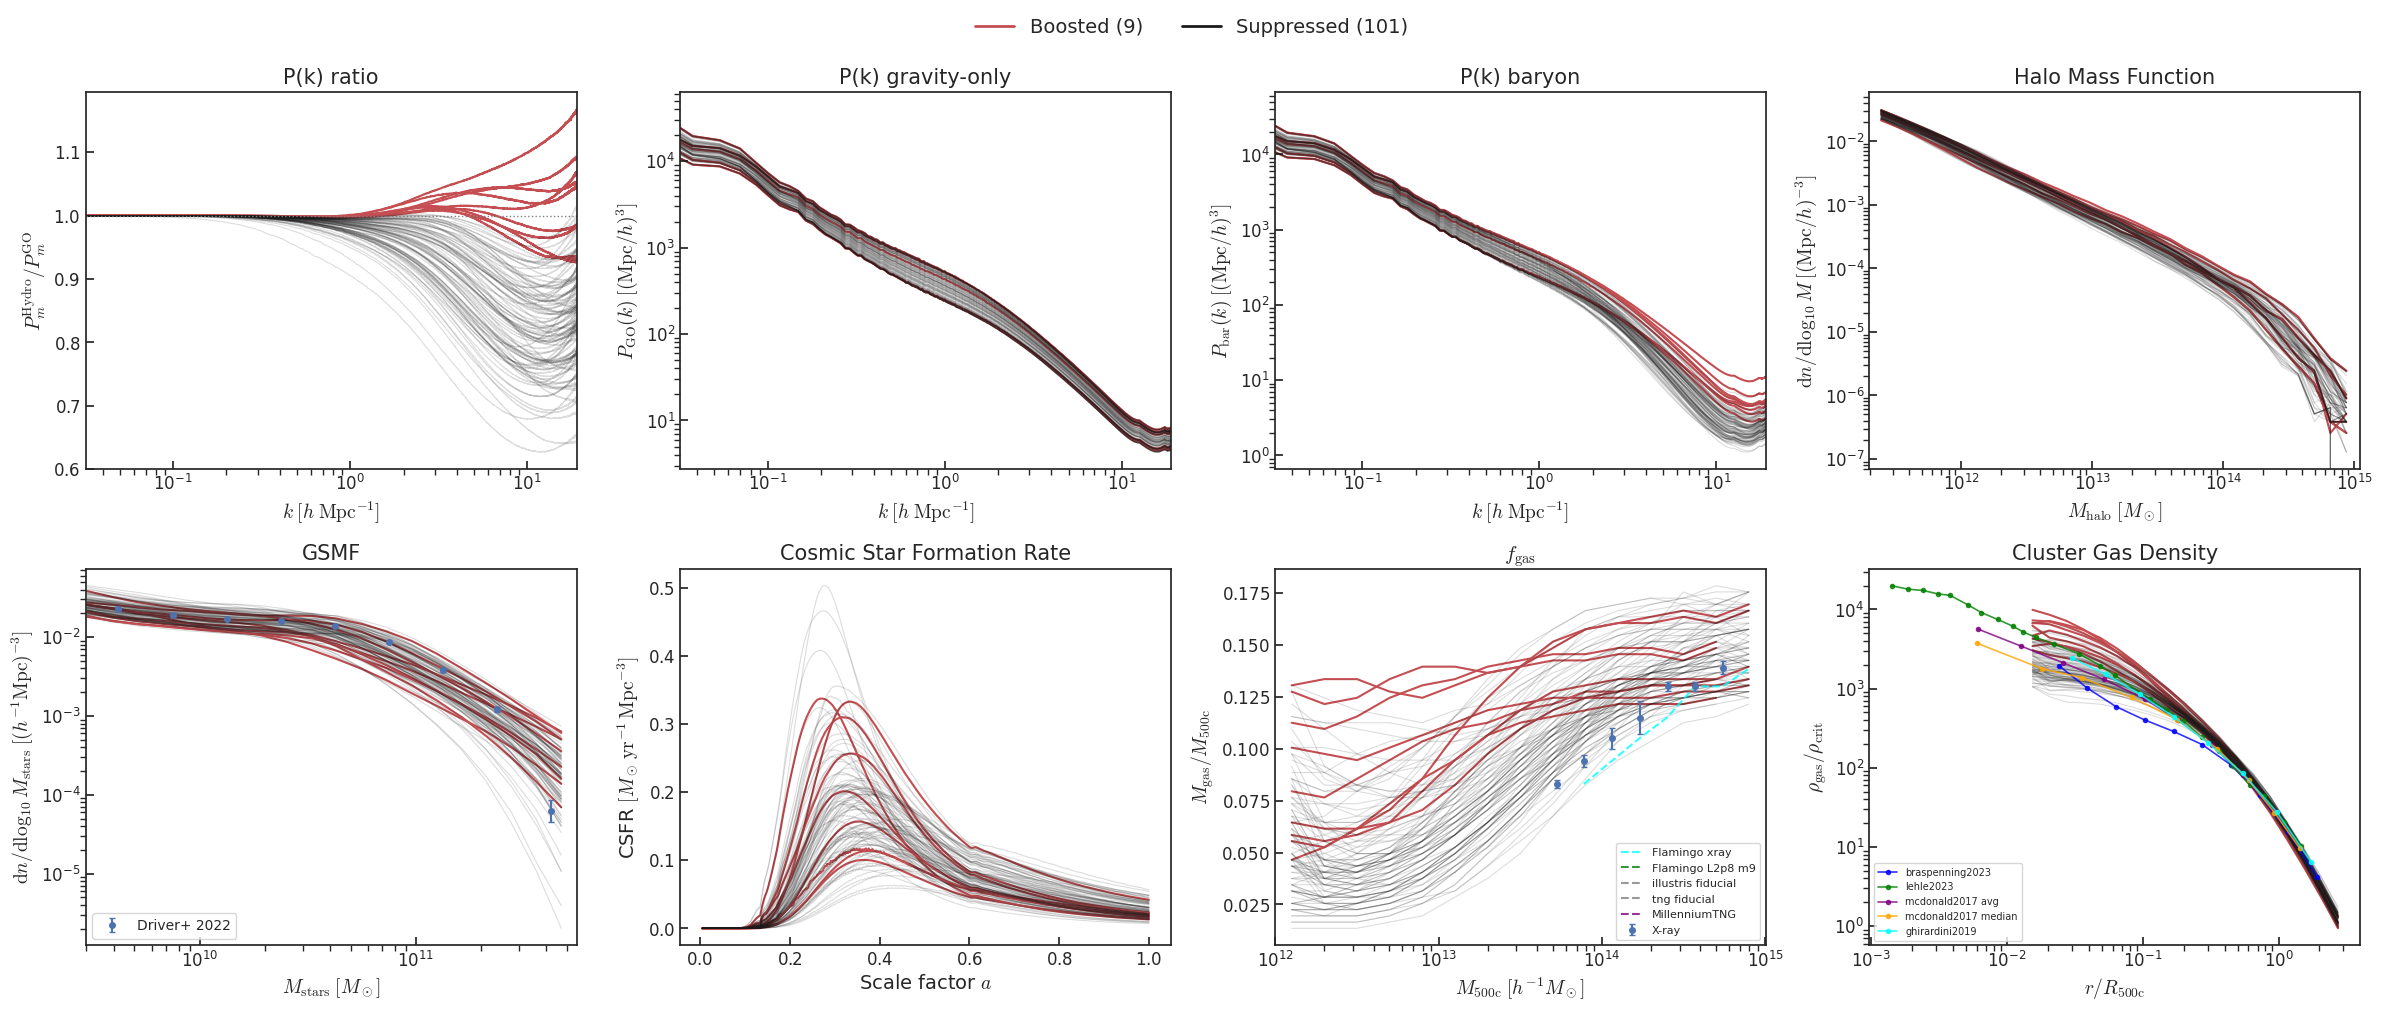

In [14]:
## ---- 4x2 subplot: boosted (red) vs suppressed (black) + obs data ----
from matplotlib.lines import Line2D

# k_xlim = 19.0

# Mass/radius limits
gsmf_mlim1, gsmf_mlim2 = [3e9, 5e11]
fgas_mlim1, fgas_mlim2 = [10**12, 10**15]
hmf_mlim1, hmf_mlim2 = [2e11, 1e15]
k_xlim1, k_xlim2 = [0.04, 19]

k_mask_plot = k_all < k_xlim2

# --- Load observational data ---
gsmf_obs_dir = '/home/nramachandra/Projects/Hydro_runs/HAvoCC/havocc/analysis/modules/galaxy_modules/GalStellarMassFunction/data/'
cgd_obs_dir = '/home/nramachandra/Projects/Hydro_runs/HAvoCC/havocc/analysis/modules/halo_profile_modules/ClusterGasDensityProfile/data/'
gasFr_obs_dir = '/home/nramachandra/Projects/Hydro_runs/HAvoCC/havocc/analysis/modules/halo_modules/Mgas_M500/data/'

gsmf_obs_x, gsmf_obs_y, gsmf_obs_yerr = load_gsmf_obs(gsmf_obs_dir)
fgas_obs_x, fgas_obs_y, fgas_obs_yerr = load_fgas_obs()
cgd_obs_data = load_cgd_obs(directory=cgd_obs_dir)
fgas_other_sims = load_fgas_other_sims(gasFr_obs_dir)

fig, axes = plt.subplots(2, 4, figsize=(24, 10))

# --- Row 1: Pk ratio, Pk GO, Pk baryon, HMF ---

# (0,0) Pk ratio = P_hydro / P_GO
ax = axes[0, 0]
for i in suppressed_idx:
    ax.plot(k_all[k_mask_plot], pk_ratio_all[i, k_mask_plot], '-', color='k', alpha=0.15, lw=0.8)
for i in boosted_idx:
    ax.plot(k_all[k_mask_plot], pk_ratio_all[i, k_mask_plot], '-', color='r', alpha=1, lw=1.5, zorder=0)
ax.axhline(y=1.0, ls=':', color='gray', lw=1.0)
ax.set_xscale('log')
ax.set_xlim(k_xlim1 * 0.8, k_xlim2)
ax.set_xlabel(r'$k \; [h \; \mathrm{Mpc}^{-1}]$', fontsize=14)
ax.set_ylabel(r'$P_m^{\mathrm{Hydro}} / P_m^{\mathrm{GO}}$', fontsize=14)
ax.set_title('P(k) ratio', fontsize=15)
ax.tick_params(labelsize=12, direction='in')

# (0,1) Pk GO
ax = axes[0, 1]
for i in suppressed_idx:
    ax.plot(k_all[k_mask_plot], pk_go_all[i, k_mask_plot], '-', color='k', alpha=0.15, lw=0.8)
for i in boosted_idx:
    ax.plot(k_all[k_mask_plot], pk_go_all[i, k_mask_plot], '-', color='r', alpha=1, lw=1.5, zorder=0)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(k_xlim1 * 0.8, k_xlim2)
ax.set_xlabel(r'$k \; [h \; \mathrm{Mpc}^{-1}]$', fontsize=14)
ax.set_ylabel(r'$P_{\mathrm{GO}}(k) \; [(\mathrm{Mpc}/h)^3]$', fontsize=14)
ax.set_title('P(k) gravity-only', fontsize=15)
ax.tick_params(labelsize=12, direction='in')

# (0,2) Pk baryon
ax = axes[0, 2]
for i in suppressed_idx:
    ax.plot(k_all[k_mask_plot], pk_bar_all[i, k_mask_plot], '-', color='k', alpha=0.15, lw=0.8)
for i in boosted_idx:
    ax.plot(k_all[k_mask_plot], pk_bar_all[i, k_mask_plot], '-', color='r', alpha=1, lw=1.5, zorder=0)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(k_xlim1 * 0.8, k_xlim2)
ax.set_xlabel(r'$k \; [h \; \mathrm{Mpc}^{-1}]$', fontsize=14)
ax.set_ylabel(r'$P_{\mathrm{bar}}(k) \; [(\mathrm{Mpc}/h)^3]$', fontsize=14)
ax.set_title('P(k) baryon', fontsize=15)
ax.tick_params(labelsize=12, direction='in')

# (0,3) HMF
ax = axes[0, 3]
hmf_mask = (hmf_mass > hmf_mlim1) & (hmf_mass < hmf_mlim2)
for i in suppressed_idx:
    ax.plot(hmf_mass[hmf_mask], hmf_all[i, hmf_mask], '-', color='k', alpha=0.15, lw=0.8)
for i in boosted_idx:
    ax.plot(hmf_mass[hmf_mask], hmf_all[i, hmf_mask], '-', color='r', alpha=1, lw=1.5, zorder=0)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.99 * hmf_mlim1, 1.11 * hmf_mlim2)
ax.set_xlabel(r'$M_{\mathrm{halo}} \; [M_\odot]$', fontsize=14)
ax.set_ylabel(r'$\mathrm{d}n / \mathrm{d}\log_{10} M \; [(\mathrm{Mpc}/h)^{-3}]$', fontsize=14)
ax.set_title('Halo Mass Function', fontsize=15)
ax.tick_params(labelsize=12, direction='in')

# --- Row 2: GSMF, CSFR, fGas, CGD ---

# (1,0) GSMF + obs
ax = axes[1, 0]
gsmf_mask = (stellar_mass > gsmf_mlim1) & (stellar_mass < gsmf_mlim2)
for i in suppressed_idx:
    ax.plot(stellar_mass[gsmf_mask], gsmf_all[i, gsmf_mask], '-', color='k', alpha=0.15, lw=0.8)
for i in boosted_idx:
    ax.plot(stellar_mass[gsmf_mask], gsmf_all[i, gsmf_mask], '-', color='r', alpha=1, lw=1.5, zorder=0)
# Obs: Driver+ 2022
gsmf_obs_mask = (gsmf_obs_x > gsmf_mlim1) & (gsmf_obs_x < gsmf_mlim2)
ax.errorbar(gsmf_obs_x[gsmf_obs_mask], gsmf_obs_y[gsmf_obs_mask],
            yerr=gsmf_obs_yerr[:, gsmf_obs_mask], fmt='o', color='b', ms=4,
            capsize=2, label='Driver+ 2022', zorder=5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.99 * gsmf_mlim1, 1.11 * gsmf_mlim2)
ax.set_xlabel(r'$M_{\mathrm{stars}} \; [M_\odot]$', fontsize=14)
ax.set_ylabel(r'$\mathrm{d}n / \mathrm{d}\log_{10} M_{\mathrm{stars}} \; [(h^{-1}\mathrm{Mpc})^{-3}]$', fontsize=14)
ax.set_title('GSMF', fontsize=15)
ax.legend(fontsize=10, loc='lower left')
ax.tick_params(labelsize=12, direction='in')

# (1,1) CSFR
ax = axes[1, 1]
for i in suppressed_idx:
    ax.plot(scale_factor_csfr, csfr_all[i], '-', color='k', alpha=0.15, lw=0.8)
for i in boosted_idx:
    ax.plot(scale_factor_csfr, csfr_all[i], '-', color='r', alpha=1, lw=1.5, zorder=0)
# ax.set_yscale('log')
ax.set_xlabel(r'Scale factor $a$', fontsize=14)
ax.set_ylabel(r'CSFR $[M_\odot \, \mathrm{yr}^{-1} \, \mathrm{Mpc}^{-3}]$', fontsize=14)
ax.set_title('Cosmic Star Formation Rate', fontsize=15)
ax.tick_params(labelsize=12, direction='in')

# (1,2) Gas fraction + obs
ax = axes[1, 2]
halo_mass_lin = 10**log_halo_mass
fgas_mask = (halo_mass_lin > fgas_mlim1) & (halo_mass_lin < fgas_mlim2)
for i in suppressed_idx:
    ax.plot(halo_mass_lin[fgas_mask], fgas_all[i, fgas_mask], '-', color='k', alpha=0.15, lw=0.8)
for i in boosted_idx:
    ax.plot(halo_mass_lin[fgas_mask], fgas_all[i, fgas_mask], '-', color='r', alpha=1, lw=1.5, zorder=0)
# Obs: X-ray (Kugel+ 2023)
ax.errorbar(fgas_obs_x, fgas_obs_y, yerr=fgas_obs_yerr, fmt='o', color='b',
            ms=4, capsize=2, label='X-ray', zorder=5)
# Other sims
sim_colors = {'Flamingo_L2p8_m9': 'green', 'MillenniumTNG': 'purple', 'Flamingo_xray': 'cyan'}
for source, (sx, sy) in fgas_other_sims.items():
    clr = sim_colors.get(source, 'gray')
    ax.plot(10**sx, sy, '--', color=clr, lw=1.5, alpha=0.8, label=source.replace('_', ' '), zorder=4)
ax.set_xscale('log')
ax.set_xlim(0.99 * fgas_mlim1, 1.01 * fgas_mlim2)
ax.set_xlabel(r'$M_{\mathrm{500c}} \; [h^{-1} M_\odot]$', fontsize=14)
ax.set_ylabel(r'$M_{\mathrm{gas}} / M_{\mathrm{500c}}$', fontsize=14)
ax.set_title(r'$f_{\mathrm{gas}}$', fontsize=15)
ax.legend(fontsize=8, loc='lower right')
ax.tick_params(labelsize=12, direction='in')

# (1,3) CGD + obs
ax = axes[1, 3]
for i in suppressed_idx:
    ax.plot(radius_cgd, cgd_all[i], '-', color='k', alpha=0.15, lw=0.8)
for i in boosted_idx:
    ax.plot(radius_cgd, cgd_all[i], '-', color='r', alpha=1, lw=1.5, zorder=0)
# Obs: multiple CGD profile sources
obs_colors = ['blue', 'green', 'purple', 'orange', 'cyan', 'brown']
for ci, (source, (rx, ry)) in enumerate(cgd_obs_data.items()):
    clr = obs_colors[ci % len(obs_colors)]
    label = source.replace('_', ' ').replace('rho z0', '').strip()
    if ry.ndim > 1:
        ax.plot(rx, ry[:, 0], 'o-', color=clr, ms=3, lw=1.2, alpha=0.8, label=label, zorder=5)
    else:
        ax.plot(rx, ry, 'o-', color=clr, ms=3, lw=1.2, alpha=0.8, label=label, zorder=5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$r / R_{\mathrm{500c}}$', fontsize=14)
ax.set_ylabel(r'$\rho_{\mathrm{gas}} / \rho_{\mathrm{crit}}$', fontsize=14)
ax.set_title('Cluster Gas Density', fontsize=15)
ax.legend(fontsize=7, loc='lower left')
ax.tick_params(labelsize=12, direction='in')

# Legend
legend_elements = [Line2D([0], [0], color='r', lw=2, label=f'Boosted ({len(boosted_idx)})'),
                   Line2D([0], [0], color='k', lw=2, label=f'Suppressed ({len(suppressed_idx)})')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=14,
           bbox_to_anchor=(0.5, 1.02), frameon=False)

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('../plots/Pk_boosted_vs_suppressed_4x2.png', bbox_inches='tight', dpi=150)
plt.show()